# Single-Cell Transcriptomics Workshop Part 1: 
## Preprocessing and Visualization with Scanpy

We'll jump right into a step-by-step workflow using Scanpy to analyze a scRNA-Seq dataset. Here, we are using a cohort of healthy and COVID-19 patients. 

For all samples, single-cell RNA sequencing ([10x Genomics](https://www.10xgenomics.com/what-is-single-cell-rna-seq)) was performed using peripheral blood mononuclear cells (PBMCs). Samples were collected from:
* Healthy donors (**n = 4**)
* Patients with COVID-19 of varying clinical severity, including severe, mild, and asymptomatic (**n = 8**)

*(Source: [Lee et al., 2020](https://doi.org/10.1126/sciimmunol.abd1554))*

---

Be mindful that this notebook will guide you through each step, but **you will need to complete code snippets** to get familiar with the structure and syntax of the analysis. 

Your best friends will be the [Scanpy documentation](https://scanpy.readthedocs.io/en/stable/index.html) and the [single-cell best practices guide](https://www.sc-best-practices.org/preamble.html) that this workshop is based on. Both of these resources will have more detailed information if at any step you are unsure or have more questions. 

Be aware that this workshop is aimed to be a **high-level overview** to help you get familiar with the entire scRNA-Seq analysis pipeline. By no way are we going in depth at any of the many complex steps in the analysis: if you are curious to read more in depth about any step along the way, we refer you to the single cell best practices guide which references literature for future reading. 

Have fun!

In [2]:
import pandas as pd 
import numpy as np 
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

## Get familiar with the anndata format

[Anndata](https://anndata.readthedocs.io/en/latest/index.html#) is a Python package for handling annotated data matrices. scRNA-Seq data is inherently high dimensional: our matrix dimensions are the `number of barcodes x number of transcripts`, that is, roughly, `number of cells x number of genes` where the barcodes (cells) are refered to as the `obs` and the genes are refered to as the `vars`. (Note on barcodes vs cells: before preprocessing, we are not sure that each measure is indeed a 'healthy' cell, thus, we refer to them as barcodes for clarity). In our anndata object, we store a matrix, referred to as `adata.X`, with these raw count values. However, we also have metadata we want to keep track: each row in the `adata.X` matrix corresponds to a single cell from a specific patient, with corresponding metadata (patient disease state, sample experimental batch, etc.). The metadata for each `obs` row is stored in a Pandas dataframe `adata.obs`. Similarly, for each column in the `adata.X` matrix we want to keep track of what gene it is and any metadata for that gene (highly variable, marker gene, etc.). This is stored in the dataframe `adata.vars`. 

We may also have metadata at either level (`obs` or `vars`) that has many dimensions to it (numerical embeddings like UMAP which we'll see later in the notebook). These are stored in the `adata.obsm` and `adata.varm` attributes. 

<img src='./images/anndata_schema.svg' alt='anndata schema' width=600/>

In [3]:
# load scRNA-Seq data from h5ad file
adata = sc.read_h5ad("data/adata_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 70597 × 33538
    obs: 'sample_number', 'sample_id', 'disease_state', 'age', 'sex', 'batch'
    var: 'gene_ids', 'feature_types'

## Exercise: explore the adata object

Can you find how to display the contents of the `adata.obs`? How many samples are there? What disease states are there? How many experimental batches are there? 

**Hint**: Use the exact `adata.obs` syntax to display the sample-level metadata dataframe. Then, use regular Pandas syntax to explore the column-level values. 

In [ ]:
# your code to inspect the adata object



## Preprocessing and Quality Control (QC)

Single-cell RNA-seq datasets have two essential properties that one should have in mind when performing an analysis. First, scRNA-seq data contains **drop-outs**, meaning there is an excessive number of zeros in the data due to the limitation of mRNA. Second, the potential for correcting the data and performing quality control might be limited as the **data may be confounded with biology**. It is therefore crucial to select preprocessing methods that are suitable for the underlying data without overcorrecting or removing biological effects.

<img src='./images/quality_control.jpeg' width=800>

## Filtering low quality cells

The first step in quality control is to remove low-quality cells from the dataset. When a cell has a low number of detected genes, a low count depth, and a high fraction of mitochondrial counts it might have a broken membrane which can indicate a dying cell. As these cells are usually not the main target of our analysis and might distort our downstream analysis, we remove them during quality control. To identify them, we define the cell quality control (QC) threshold. Cell QC is typically performed on the following three QC covariates:

- The number of counts per barcode (count depth)

- The number of genes per barcode

- The fraction of counts from mitochondrial genes per barcode



In [4]:
# First, we need to identify mitochondrial genes, ribosomal genes, and hemoglobin genes in order to differentiate which is which for our QC metrics.

# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")

adata.var.head()

,gene_ids,feature_types,mt,ribo,hb
MIR1302-2HG,ENSG00000243485,Gene Expression,False,False,False
FAM138A,ENSG00000237613,Gene Expression,False,False,False
OR4F5,ENSG00000186092,Gene Expression,False,False,False
AL627309.1,ENSG00000238009,Gene Expression,False,False,False
AL627309.3,ENSG00000239945,Gene Expression,False,False,False


In [5]:
# we can now calculate the respective QC metrics using a built-in scanpy function

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 70597 × 33538
    obs: 'sample_number', 'sample_id', 'disease_state', 'age', 'sex', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Exercise: explore the QC values calculated

As you can see, a couple of new columns were added to the metadata: 

- `n_genes_by_counts` in `adata.obs` is the number of genes with positive counts in a cell,

- `total_counts` is the total number of counts for a cell, this might also be known as library size, and

- `pct_counts_mt` is the proportion of total counts for a cell which are mitochondrial.

**Can you plot the distribution of the `total_counts` values in `adata.obs` to visually inspect the number of counts (i.e. the number of genes expressed in each cell) in all the cells in our dataset?**

**Hint:** use `sns.displot` or `plt.hist` !

What does this distribution tell us about necessary QC filtering? Remember, low count depth may indicate dying cells with broken membranes. 

In [28]:
# your code to plot the total_counts in the dataset



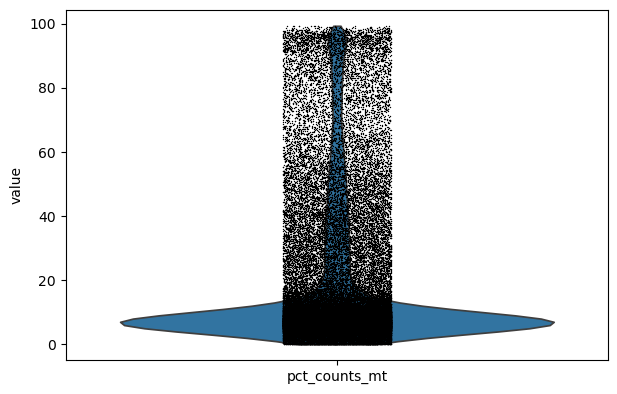

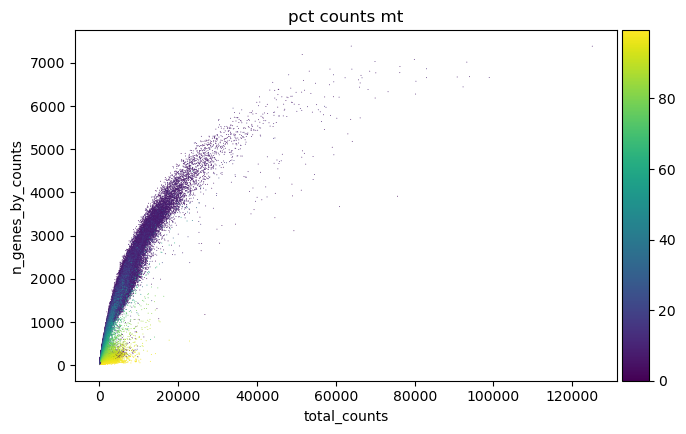

In [6]:
# we can also plot additional QC metrics such as the percentage of mitochondrial genes
p2 = sc.pl.violin(adata, "pct_counts_mt")
# and the relationship between total counts and number of genes detected, colored by percentage of mitochondrial genes
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Setting thresholds for QC filtering

The plots indicate that some cells have a relatively high percentage of mitochondrial counts which are often associated with cell degradation. Based on these plots, we will show QC with automatic thresholding and filtering based on **median absolute deviation (MAD)**, defined as the median of the distances of all data points from the data's median. This metric is more robust to outliers than a similar measure of data distribution around a center value like the standard deviation. We want a metric that **perserves a representation of the typical cell in our dataset** and isn't skewed by extremely high or low outliers, i.e. some cells with extremely high mitocondrial percentage values. 

The MAD helps us automatically identify cells we should filter out based on a thresholding approach: 

first, we define the method `is_outlier` to classify cells as outliers if they differ by more than 5 MADs, which is a relatively permissive filtering strategy. We apply this filter to the `total_counts`, `n_genes_by_counts`, and `pct_counts_in_top_20_genes` columns (often, we use the log transformed values to better quantify highly skewed counts. Look at the histogram you plotted earlier: there is a large ranges of values while most cells cluster around low total counts. Taking the log of the data helps transform this distribution into a more symmetrical shape. If you're curious, try plotting the same histogram but with the `log1p_total_counts` column and compare, especially the x-axis values!)

In [7]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    56653
True     13944
Name: count, dtype: int64

For the percentage of mitochondrial counts, we will use a more permissive MAD threshold of 3, but we also want to manually set an upper limit of the max amount of % mito genes allowed after filtering. Have a look at the above plots that show the distribution of the mitochondrial percentage in our dataset. Can you identify a meaningful threshold for this upper limit? Ask if you are unsure. 

In [8]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 20 # your upper threshold for mitochondrial percentage here
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    52969
True     17628
Name: count, dtype: int64

In [9]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 70597
Number of cells after filtering of low quality cells: 50070


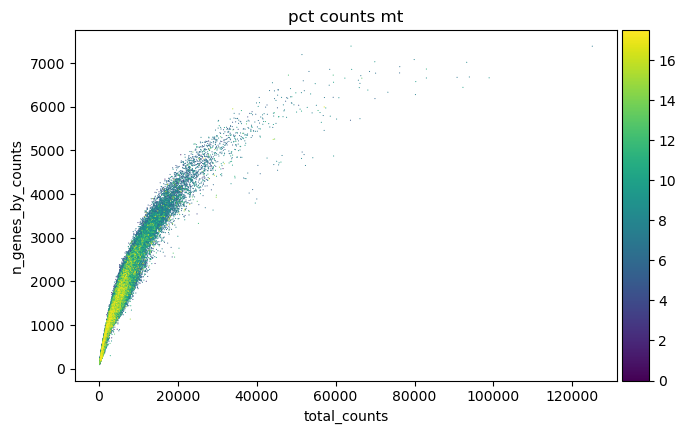

In [10]:
# now we can plot the same QC metrics again to see how they look after filtering out low quality cells! 

p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Doublet detection

**Doublets** are defined as two cells that are sequenced under the same cellular barcode—for example, if they were captured in the same droplet. That’s why we used the term *“barcode”* instead of *“cell”* until now. 

* **Homotypic doublets:** Formed by the **same cell type** (but often from different individuals). These are not necessarily identifiable from count matrices and are often considered innocuous as they can be identified with cell hashing or SNPs.
* **Heterotypic doublets:** Formed from **different cell types or states**. Their identification is crucial as they are most likely misclassified and can lead to distorted downstream analysis steps. 

Hence, doublet detection and removal are typically initial preprocessing steps. 

Doublets can be identified through two main strategies:
1.  **Metric-based:** Flagging cells with an unusually high number of reads and detected features.
2.  **Simulation-based:** Utilizing methods that create artificial doublets and compare these with the cells present in the dataset. 

Doublet detection methods are computationally efficient, and several software packages exist for this task. 

In this workflow, we will use the **Scrublet** method built into Scanpy. Briefly, the workflow functions as follows:

1.  **Simulation:** Doublets (multiplets of just two cells) are simulated from the data by combining random pairs of observed transcriptomes.
2.  **Scoring:** Each observed transcriptome is scored based on the relative densities of simulated doublets and observed transcriptomes in its local vicinity.

*(Source: [Wolock et al., 2019](https://doi.org/10.1016/j.cels.2018.11.005))*

<img src='./images/scrublet.jpg'>

<Axes: >

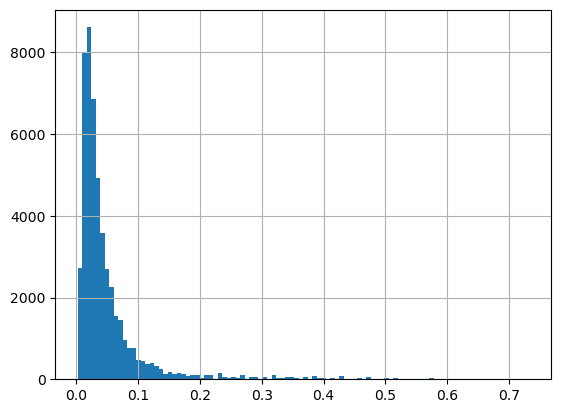

In [36]:
# this code may take a couple of minutes to run, so be patient! We are using the scrublet algorithm to identify potential doublets in our dataset.
sc.pp.scrublet(adata, batch_key="batch")
adata.obs.doublet_score.hist(bins=100)
# we leave the doublet score as is and will remove doublets after visualization and clustering

What does the doublet score distribution tell you about the quality of our dataset? Similar to the QC plots before, can you think of values that may need to be filtered out? 

Indeed **we will filter out doublets later on**, once we have visualization techniques for the whole dataset. Why? Doublet detection scores are probabilistic guesses, not ground truth. Tools like Scrublet simulate artificial doublets and score how similar each cell is to them, but this process has both false positives and false negatives. During downstream clustering it might be useful to reassess quality control and the chosen parameters to potentially filter out more or less cells based on the quality of the clustering. 

## Normalization

Up to this point, we removed low-quality cells, identified doublets from the dataset and the data is available as a count matrix. These counts represent a molecule’s capture, reverse transcription and sequencing in the scRNA-seq experiment. Each of these steps adds a degree of variability to the measured count depth for identical cells, **so the difference in gene expression between cells in the count data might simply be due to sampling effects**. This means that the dataset and therefore the count matrix still contains widely varying variance terms. Analyzing the dataset is often challenging as many statistical methods assume data with uniform variance structure.

Normalization aims to adjust the raw counts in the dataset for variable sampling effects by scaling the observable variance to a specified range. Several normalization techniques are used in practice varying in complexity. 

In [ ]:
# Saving raw count data
adata.layers["counts"] = adata.X.copy()

# syntax note: anndata allows for different versions of the data matrix to be stored in so-called layers
# we will use the normalized counts for most downstream analysis, but we can also keep the raw counts in adata.layers["counts"] for quick access

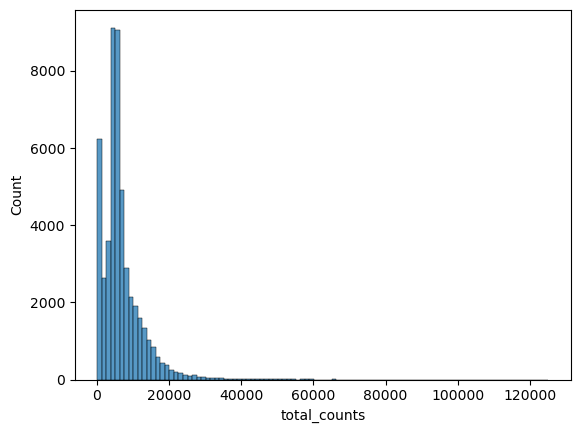

In [12]:
# inspect distribution of raw read counts, i.e. BEFORE normalization
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

Here, we will use the **shifted logarithm** normalization method. Briefly, the method applies a nonlinear function $f(Y)$ to the raw counts $Y$ and aims to make the variances across the dataset more similar. 

For more details, look here: [sc-best-practices.org/shifted-logarithm](https://www.sc-best-practices.org/preprocessing_visualization/normalization.html#shifted-logarithm)

In [14]:
# Shifted logarithm
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

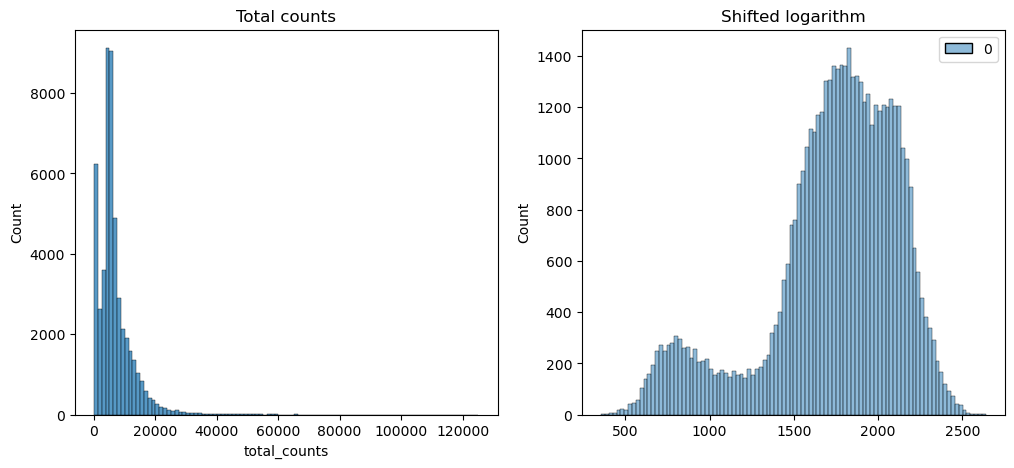

In [15]:
# now inspect the distribution of total counts before and after log1p transform
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

## Exercise: explore alternative normalization methods

The normalization above is a flavor of a popular method: counts per million (CPM) normalization. It's useful to get a feel for how different normalization techniques can change the data as this is important to understand when thinking about how it could impact your downstream analysis. 

Impliment and visualize an altenative CPM normalization below and think critically about the resulting differences. 

**Hint:** To change the shifted logarithm method used above to the CPM method, you need to change the value of `target_sum`. Look in the documentation [here](https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.normalize_total.html) on what value is needed. Use the same visualizations as above but remember to change the variable names to clearly plot the two methods. 

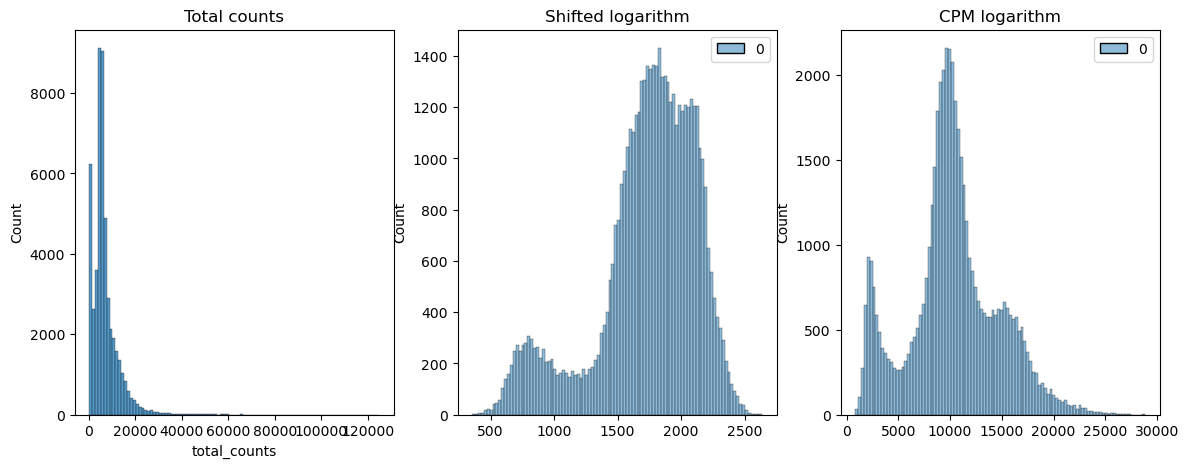

In [18]:
# CPM normalization
cpm_counts = sc.pp.normalize_total(adata, target_sum=1e6, inplace=False)
# log1p transform
adata.layers["log1p_norm_cpm"] = sc.pp.log1p(cpm_counts["X"], copy=True)

# now inspect the distribution of total counts before and after log1p transform
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
p3 = sns.histplot(adata.layers["log1p_norm_cpm"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("CPM logarithm")
plt.show()

## Feature Selection

We now have a normalized data representation that still preserves biological heterogeneity but with reduced technical sampling effects in gene expression. ScRNA-seq datasets usually contain up to 30,000 genes (depending on the organism) and so far we only removed genes that are not detected in at least 20 cells. However, many of the remaining genes are not informative and contain mostly zero counts. Therefore, a standard preprocessing pipeline involves the step of feature selection which aims to exclude uninformative genes which might not represent meaningful biological variation across samples.

Interactive: can look at effect of different 'flavor' parameter

Also how many HVGs do we choose? 2000 or 1000 or 6000? Students can play around with this (higher number means longer processing times downstream)

In [29]:
# specify the log1p normalized data as the main data matrix for downstream analysis
adata.X = adata.layers["log1p_norm"]

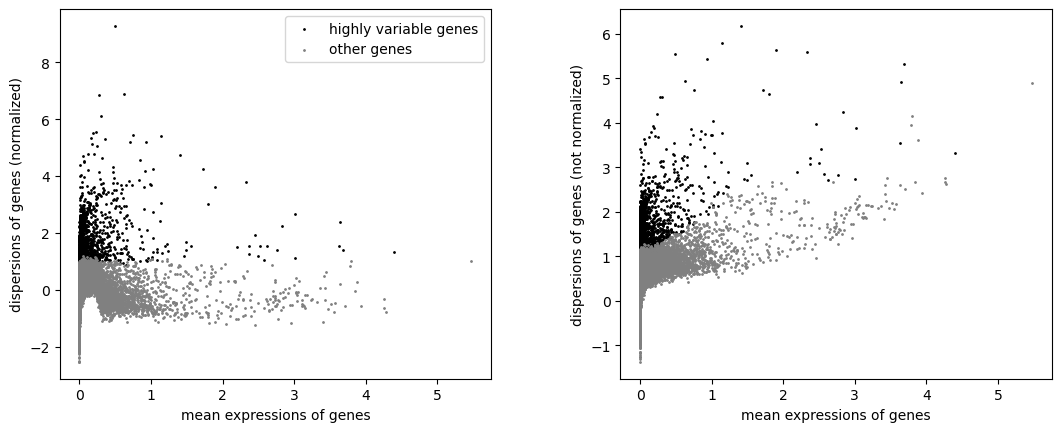

In [ ]:
# use the scanpy function to identify highly variable genes, which are often used for dimensionality reduction and clustering. 
# We specify the batch_key argument to account for batch effects in our dataset.
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="batch")
sc.pl.highly_variable_genes(adata)

## Exercise: explore different flavors of highly variable gene selection

**Task:** explore setting different values for the parameters `n_top_genes` and `flavor`. For accepted values, check the documentation [here](https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html). 

Note: for some flavor values, you may run into missing package errors. If you'd like, install these so you can test out all the options! This is not necessary though. 

In [ ]:
# your code here


## Dimensionality Reduction

scRNA-seq is a high-throughput sequencing technology that produces datasets with high dimensions in the number of cells and genes. Therefore, scRNA-seq data suffers from the [‘curse of dimensionality’](https://en.wikipedia.org/wiki/Curse_of_dimensionality).

Not all genes are informative and therefore not all genes are essential for tasks such as clustering. We already aimed to reduce the dimensionality of the data with feature selection. As a next step, we will further reduce the dimensions of single-cell RNA-seq data with dimensionality reduction algorithms. These algorithms are an important step during preprocessing to reduce the data complexity and for visualization.

Dimensionality reduction embeds the high-dimensional data into a lower-dimensional space. The low-dimensional representation still captures the underlying structure of the data while having as few dimensions as possible. Here we visualize a three-dimensional object projected into two dimensions.

<img src='./images/dimensionality_reduction.jpeg' width=800/>

## PCA

PCA creates a new set of uncorrelated variables, so-called principal components (PCs), via an orthogonal transformation of the original dataset. The PCs are linear combinations of features in the original dataset and are ranked in decreasing order of variance to define the transformation. In the ranking, the first PC typically captures the greatest amount of variance. PCs with the lowest variance are discarded to effectively reduce the dimensionality of the data without losing information.

PCA offers the advantage that it is highly interpretable and computationally efficient. However, as scRNA-seq datasets are rather sparse due to dropout events and therefore highly non-linear, visualization with the linear dimensionality reduction technique PCA is not very appropriate. PCA is typically used to select the top 10-50 PCs, which are used for downstream analysis tasks.

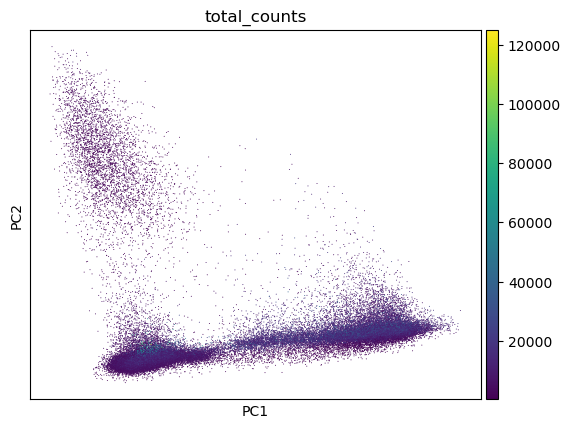

In [ ]:
# setting highly variable as highly deviant to use scanpy 'use_highly_variable' argument in sc.pp.pca

# PCA
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")
sc.pl.pca_scatter(adata, color="total_counts")

## t-Distributed Stochastic Neighbor Embeddings (t-SNE)

t-SNE is a graph based, non-linear dimensionality reduction technique which projects the high dimensional data onto 2D or 3D components. The method defines a Gaussian probability distribution based on the high-dimensional Euclidean distances between data points. Subsequently, a Student t-distribution is used to recreate the probability distribution in a low dimensional space where the embeddings are optimized using gradient descent.

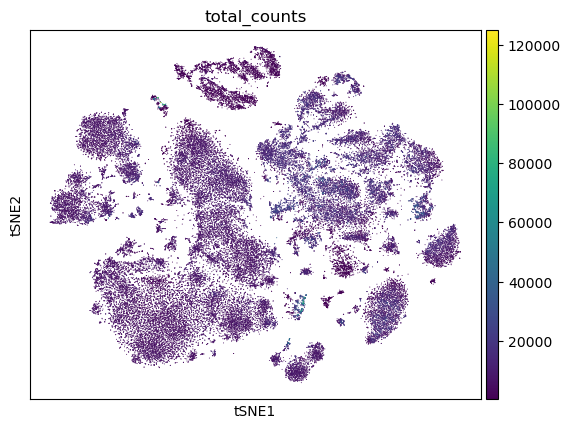

In [ ]:
# t-SNE
sc.tl.tsne(adata, use_rep="X_pca")
sc.pl.tsne(adata, color="total_counts")

## Uniform Manifold Approximation and Projection (UMAP)

UMAP is a graph-based, non-linear dimensionality reduction technique and is principally similar to t-SNE. It constructs a high-dimensional graph representation of the dataset and optimizes the low-dimensional graph representation to be as structurally similar as possible to the original graph.

We first calculate PCA (done already previously) and subsequently create a neighborhood graph based on our data.

In [36]:
# UMAP

sc.pp.neighbors(adata)
sc.tl.umap(adata)

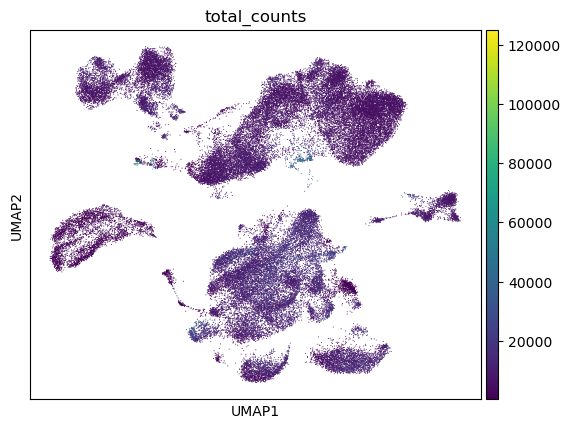

In [37]:
sc.pl.umap(adata, color="total_counts")

## Exercise: explore QC metrics across lower dimensional UMAP visualization

Previously we mentioned we would inspect QC metrics such as the doublet score closer after we visualized our data, which now we have the tools to do. 

Using the `sc.pl.umap` function, specify the columns in `adata.obs` that you want to color-code each cell by using the `color` parameter in the function. What do the results tell us? Are there any clusters that we can attribute almost entirely to a non-biological effect? 

**Hint:** try passing an array of multiple column names to visualize the different categories side-by-side. Columns of interest may be `batch` and `doublet_score`, for starters. 

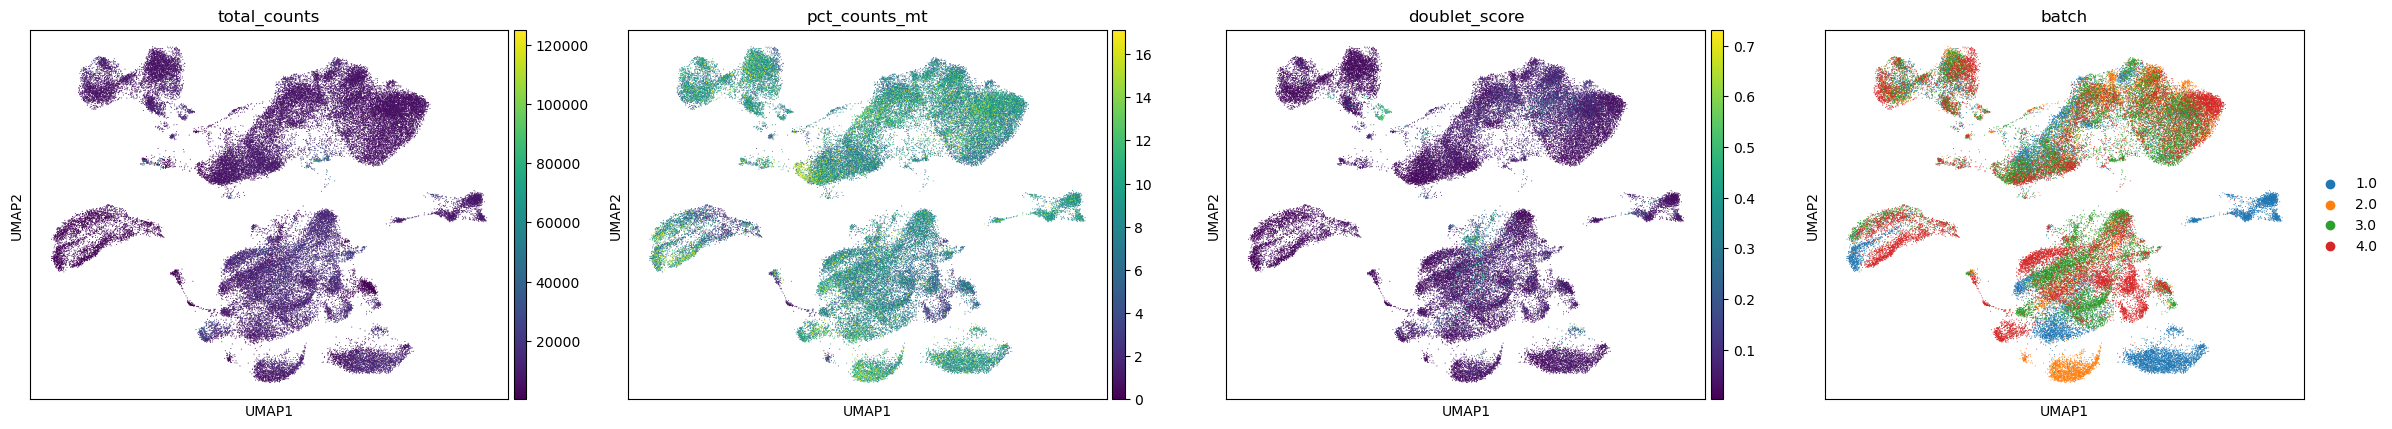

In [41]:
# inpsect QC metrics visually across dimensionality reduction embeddings to see if there are any remaining patterns of low quality cells that we missed with our previous filtering
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "doublet_score", "batch"],
)

## A note on batch effects

Maybe you've noticed  `adata.obs` contains a column with a `batch` identifier. 

A central challenge in most scRNA-seq data analyses is presented by **batch effects**. Batch effects are changes in measured expression levels that are the result of handling cells in distinct groups or “batches”. For example, a batch effect can arise if two labs have taken samples from the same cohort, but these samples are dissociated differently. 

In Part 2, we will use an already integrated (i.e. batch effect corrected, preprocessed) dataset. If you're curious on batch effect removal methods, check out the best practices guide to it here: https://www.sc-best-practices.org/cellular_structure/integration.html 